In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df = pd.read_csv('2025_data.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214147 entries, 0 to 214146
Data columns (total 33 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   BRANDS                                214147 non-null  object 
 1   BUCKETED_CUSTOMER_FREQUENCY           214147 non-null  object 
 2   BUCKETED_CUSTOMER_INCOMES             211203 non-null  object 
 3   CITY                                  214147 non-null  object 
 4   CUSTOMER_HOME_CITY                    193479 non-null  object 
 5   DAY_COUNTS                            214147 non-null  object 
 6   ISO_COUNTRY_CODE                      214147 non-null  object 
 7   LOCATION_NAME                         214147 non-null  object 
 8   MEAN_SPEND_PER_CUSTOMER_BY_FREQUENCY  214147 non-null  object 
 9   MEAN_SPEND_PER_CUSTOMER_BY_INCOME     211203 non-null  object 
 10  MEDIAN_SPEND_PER_CUSTOMER             214147 non-null  float64
 11  

In [10]:
# Check sub categories to pick out sporting goods stores

df['SUB_CATEGORY'].unique()

array(['Hobby, Toy, and Game Stores',
       'Sewing, Needlework, and Piece Goods Stores',
       'Sporting Goods Stores', 'Musical Instrument and Supplies Stores',
       nan], dtype=object)

In [11]:
# Top 5 brands by store count

df_sg = df[df['SUB_CATEGORY'] == 'Sporting Goods Stores'].copy()
df_sg.groupby('LOCATION_NAME')['PLACEKEY'].nunique().sort_values(ascending=False).head(5)

,PLACEKEY
LOCATION_NAME,
Hibbett Sports,864
Dick's Sporting Goods,789
Big 5 Sporting Goods,425
Champs Sports,365
Academy Sports + Outdoors,309


In [12]:
# Keep data from the top 5 brands

top_5_brands = ["Hibbett Sports", "Dick's Sporting Goods", "Big 5 Sporting Goods", "Champs Sports", "Academy Sports + Outdoors"]
df_sgt5 = df_sg[df_sg['LOCATION_NAME'].isin(top_5_brands)]

## Data Cleaning

In [13]:
# Check and remove duplicates

print(df_sgt5.duplicated().sum())
df_sgt5.drop_duplicates(inplace=True)

2391


/tmp/ipython-input-3535277762.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sgt5.drop_duplicates(inplace=True)


In [14]:
# Check for null values

df_sgt5.isnull().sum()

,0
BRANDS,0
BUCKETED_CUSTOMER_FREQUENCY,0
BUCKETED_CUSTOMER_INCOMES,130
CITY,0
CUSTOMER_HOME_CITY,1357
DAY_COUNTS,0
ISO_COUNTRY_CODE,0
LOCATION_NAME,0
MEAN_SPEND_PER_CUSTOMER_BY_FREQUENCY,0
MEAN_SPEND_PER_CUSTOMER_BY_INCOME,130


In [15]:
# Drop CUSTOMER_HOME_CITY and PARENT_PLACEKEY because they are not useful

df_sgt5.drop(['CUSTOMER_HOME_CITY', 'PARENT_PLACEKEY'], axis=1, inplace=True)

/tmp/ipython-input-3679018150.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sgt5.drop(['CUSTOMER_HOME_CITY', 'PARENT_PLACEKEY'], axis=1, inplace=True)


In [16]:
# Replace null values in BUCKETED_CUSTOMER_INCOMES and MEAN_SPEND_PER_CUSTOMER_BY_INCOME with same PLACEKEY's (store) values

bucketed_income_reference = df_sgt5.groupby('PLACEKEY')['BUCKETED_CUSTOMER_INCOMES'].first()
df_sgt5.fillna({'BUCKETED_CUSTOMER_INCOMES' : df_sgt5['PLACEKEY'].map(bucketed_income_reference)}, inplace=True)

mean_spend_reference = df_sgt5.groupby('PLACEKEY')['MEAN_SPEND_PER_CUSTOMER_BY_INCOME'].first()
df_sgt5.fillna({'MEAN_SPEND_PER_CUSTOMER_BY_INCOME' : df_sgt5['PLACEKEY'].map(mean_spend_reference)}, inplace=True)

/tmp/ipython-input-3148417224.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sgt5.fillna({'BUCKETED_CUSTOMER_INCOMES' : df_sgt5['PLACEKEY'].map(bucketed_income_reference)}, inplace=True)
/tmp/ipython-input-3148417224.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sgt5.fillna({'MEAN_SPEND_PER_CUSTOMER_BY_INCOME' : df_sgt5['PLACEKEY'].map(mean_spend_reference)}, inplace=True)


In [17]:
df_sgt5['PLACEKEY'].nunique()

2752

In [18]:
# Drop locations that don't have all months data

removal_check = 0

for i in df_sgt5['PLACEKEY'].unique():
    if len(df_sgt5[df_sgt5['PLACEKEY'] == i]) == 11:
        pass
    else:
        df_sgt5.drop(df_sgt5[df_sgt5['PLACEKEY'] == i].index, inplace=True)
        removal_check += 1

print(df_sgt5['PLACEKEY'].nunique())
print(removal_check)

/tmp/ipython-input-2759834901.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sgt5.drop(df_sgt5[df_sgt5['PLACEKEY'] == i].index, inplace=True)


1492
1260


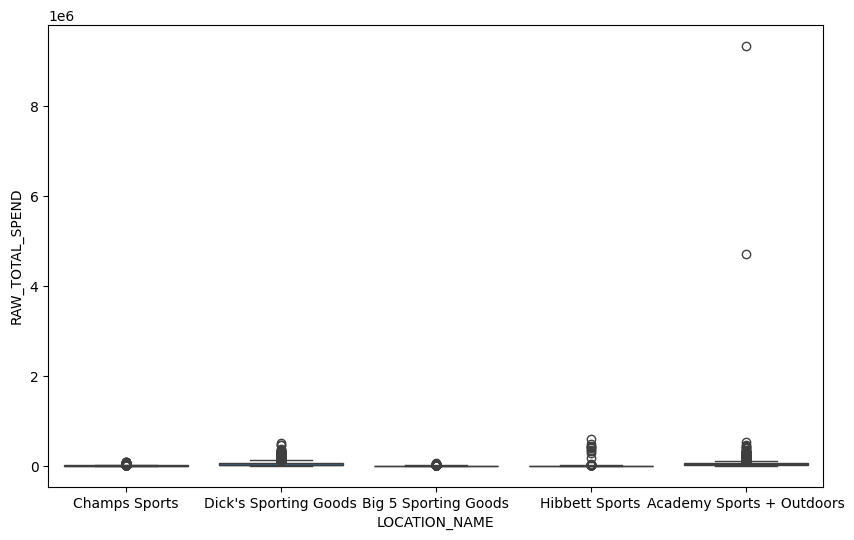

In [19]:
# Check for outliers

temp0 = df_sgt5.copy()

plt.figure(figsize=(10, 6))

sns.boxplot(temp0, x='LOCATION_NAME', y='RAW_TOTAL_SPEND')
plt.show()

In [20]:
# Add SPEND_MONTH column

temp0['SPEND_MONTH'] = pd.to_datetime(temp0['SPEND_DATE_RANGE_START']).dt.month

In [21]:
# Extreme outliers are from Academy Sports. Check and remove

temp0[temp0['LOCATION_NAME']=='Academy Sports + Outdoors'][['PLACEKEY', 'RAW_TOTAL_SPEND', 'SPEND_MONTH']].sort_values(by='RAW_TOTAL_SPEND', ascending=False).head()

,PLACEKEY,RAW_TOTAL_SPEND,SPEND_MONTH
209849,223-222@5qv-t5v-h3q,9350603.41,11
178536,223-222@5qv-t5v-h3q,4719331.94,10
97429,223-222@5px-8p9-fcq,531754.89,6
40513,223-222@5px-8p9-fcq,453079.87,3
124582,223-222@5px-8p9-fcq,432999.81,7


In [22]:
temp0[temp0['PLACEKEY'] == '223-222@5qv-t5v-h3q'][['RAW_TOTAL_SPEND', 'SPEND_MONTH']]

,RAW_TOTAL_SPEND,SPEND_MONTH
10740,320.23,1
24779,1177.44,2
44328,17418.51,3
54860,20321.75,4
86237,27238.51,5
94363,31502.52,6
110120,25853.37,7
144388,29129.86,8
154204,19780.77,9
178536,4719331.94,10


In [23]:
# Cleaned dataframe for top 5 companies analysis

df_sgt5_cleaned = temp0.drop(index=[178536, 209849])

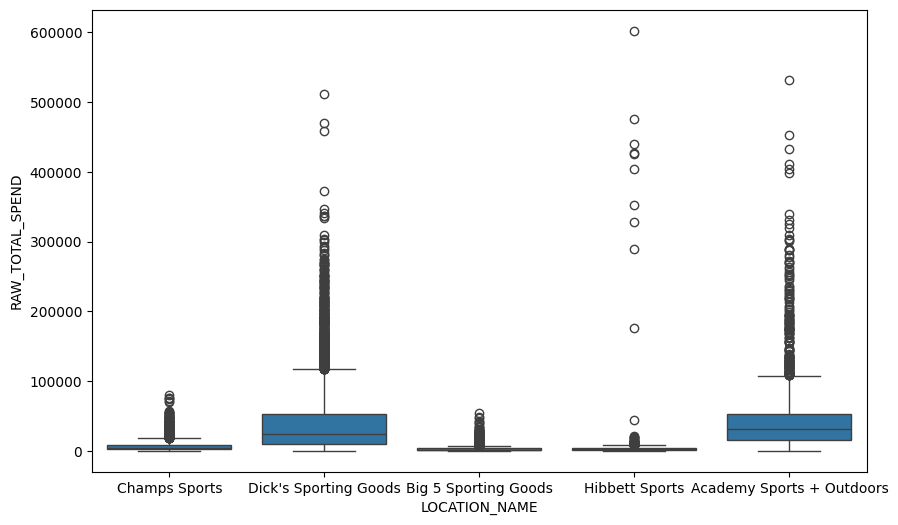

In [24]:
# The remaining high sales are possibly in flagship stores

plt.figure(figsize=(10, 6))
sns.boxplot(df_sgt5_cleaned, x='LOCATION_NAME', y='RAW_TOTAL_SPEND')

plt.show()

## Data Exploratory Analysis

### Sales trend at top 5 companies

In [25]:
# Total transaction spending by month

spend_by_month = df_sgt5_cleaned.groupby(['LOCATION_NAME', 'SPEND_MONTH'])['RAW_TOTAL_SPEND'].sum()
spend_by_month = spend_by_month.reset_index()

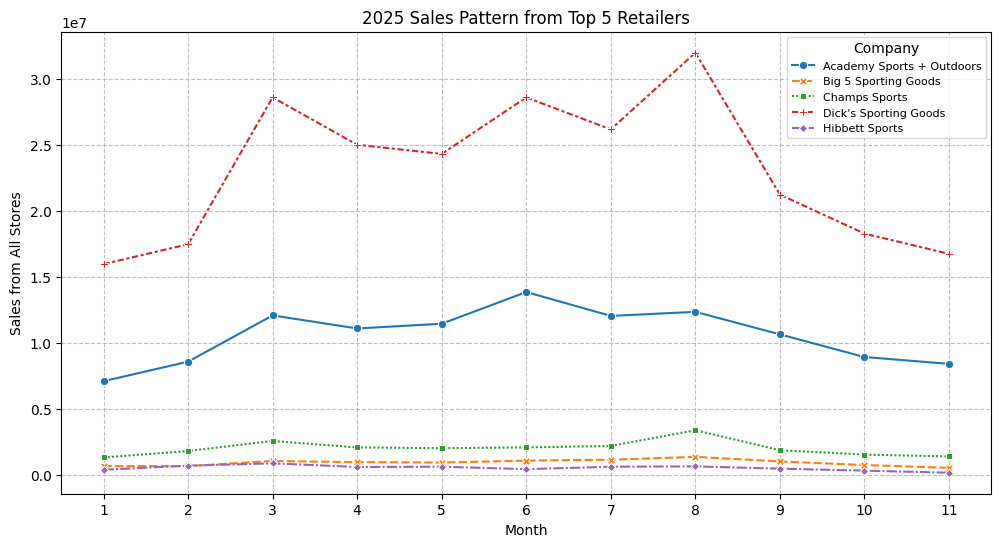

In [26]:
plt.figure(figsize=(12, 6))
plt.grid(True, linestyle='--', alpha=0.8)

sns.lineplot(spend_by_month, x='SPEND_MONTH', y='RAW_TOTAL_SPEND', hue='LOCATION_NAME',style='LOCATION_NAME', markers=True)
plt.xticks(range(1,12))
plt.xlabel('Month')
plt.ylabel('Sales from All Stores')
plt.legend(title='Company', fontsize=8)
plt.title('2025 Sales Pattern from Top 5 Retailers')
plt.show()

### Look into Dick's Sporting Goods

In [27]:
dicks = df_sgt5_cleaned[df_sgt5_cleaned['LOCATION_NAME'] == "Dick's Sporting Goods"]
dicks = dicks.reset_index(drop=True)

In [28]:
dicks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6347 entries, 0 to 6346
Data columns (total 32 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   BRANDS                                6347 non-null   object 
 1   BUCKETED_CUSTOMER_FREQUENCY           6347 non-null   object 
 2   BUCKETED_CUSTOMER_INCOMES             6347 non-null   object 
 3   CITY                                  6347 non-null   object 
 4   DAY_COUNTS                            6347 non-null   object 
 5   ISO_COUNTRY_CODE                      6347 non-null   object 
 6   LOCATION_NAME                         6347 non-null   object 
 7   MEAN_SPEND_PER_CUSTOMER_BY_FREQUENCY  6347 non-null   object 
 8   MEAN_SPEND_PER_CUSTOMER_BY_INCOME     6347 non-null   object 
 9   MEDIAN_SPEND_PER_CUSTOMER             6347 non-null   float64
 10  MEDIAN_SPEND_PER_TRANSACTION          6347 non-null   float64
 11  NAICS_CODE       

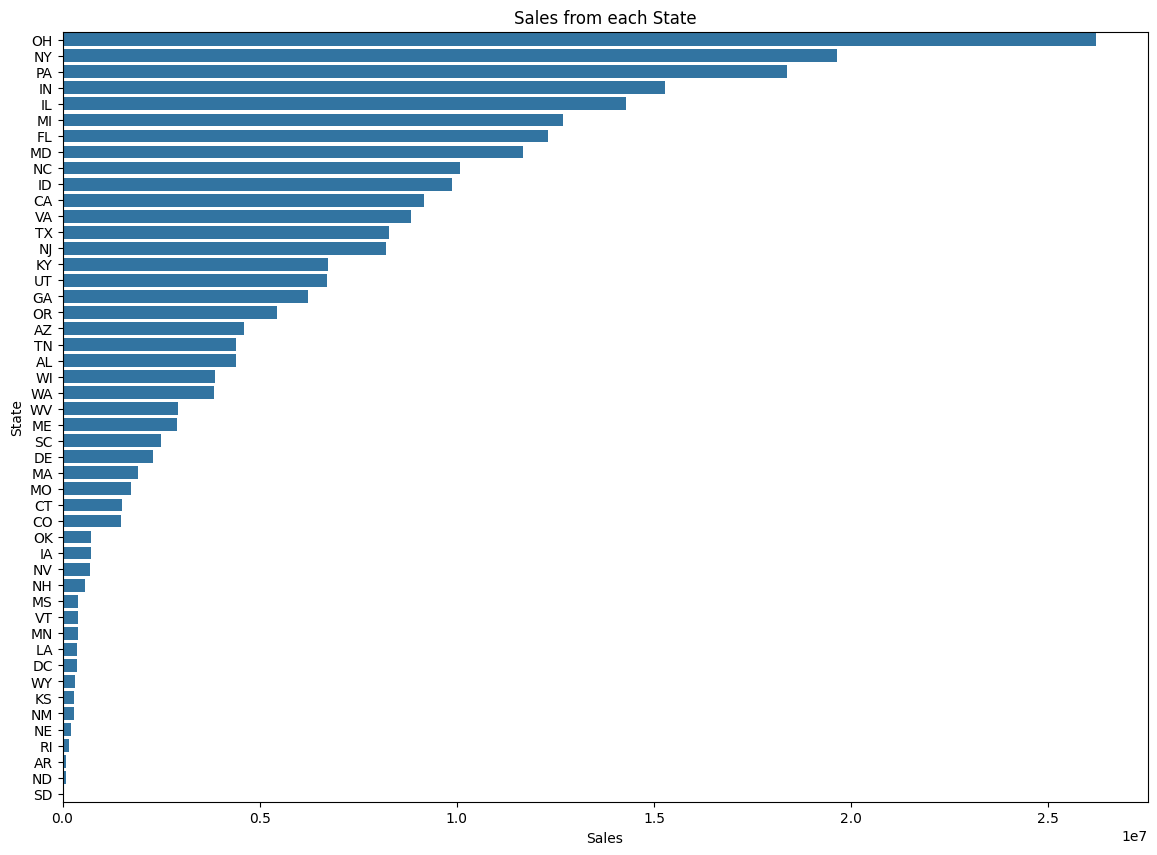

In [29]:
region_sales = dicks.groupby('REGION')['RAW_TOTAL_SPEND'].sum().reset_index().sort_values(by='RAW_TOTAL_SPEND', ascending=False)

plt.figure(figsize=(14, 10))
sns.barplot(region_sales, x='RAW_TOTAL_SPEND', y='REGION')
plt.xlabel('Sales')
plt.ylabel('State')
plt.title('Sales from each State')
plt.show()

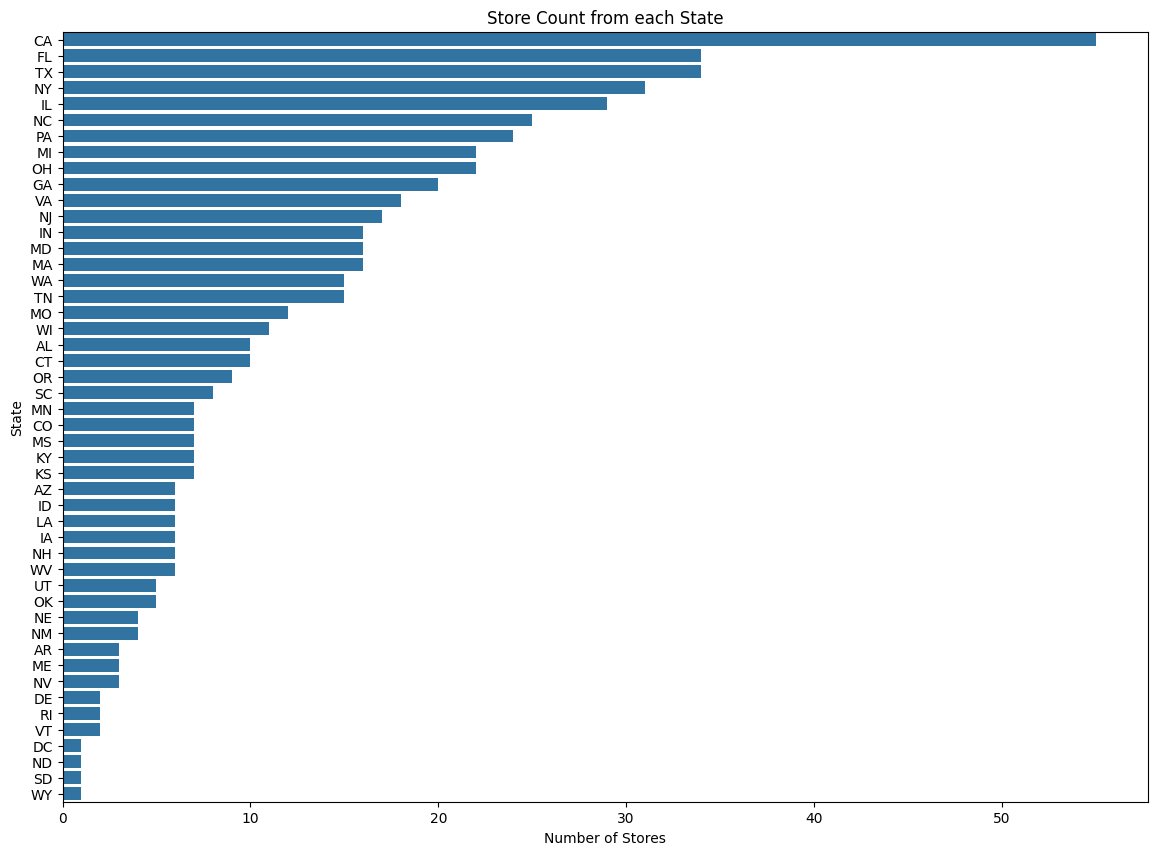

In [30]:
region_store_count = dicks.groupby('REGION')['PLACEKEY'].nunique().reset_index().sort_values(by='PLACEKEY', ascending=False)

plt.figure(figsize=(14, 10))
sns.barplot(region_store_count, x='PLACEKEY', y='REGION')
plt.xlabel('Number of Stores')
plt.ylabel('State')
plt.title('Store Count from each State')
plt.show()

*Note: There is no store in Alaska and Hawaii.*

In [31]:
region_store_count.sort_values(by='PLACEKEY', ascending=False).reset_index(drop=True).head(10)

,REGION,PLACEKEY
0,CA,55
1,FL,34
2,TX,34
3,NY,31
4,IL,29
5,NC,25
6,PA,24
7,MI,22
8,OH,22
9,GA,20


In [32]:
dicks_by_region = dicks.groupby('REGION').agg({'RAW_TOTAL_SPEND':'sum', 'PLACEKEY':'nunique'}).reset_index()

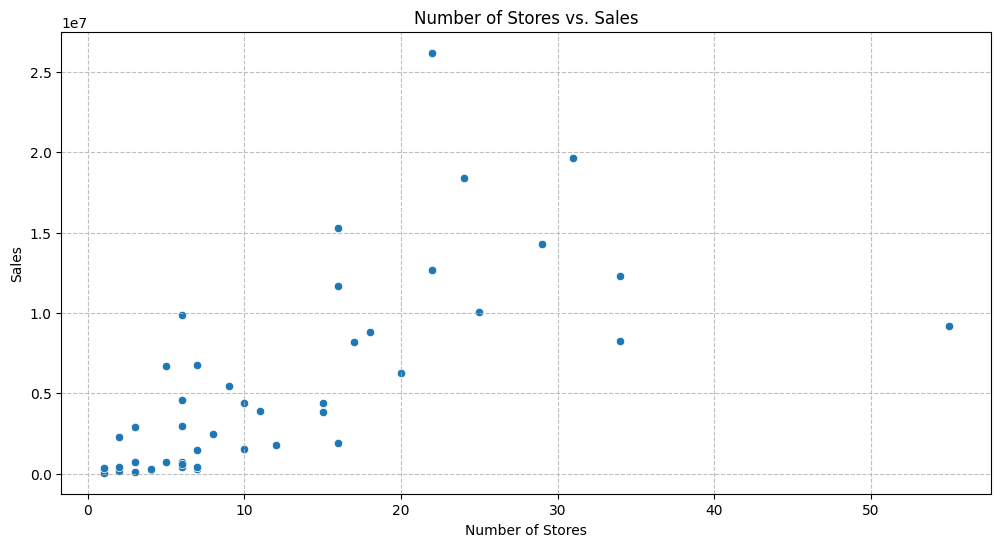

In [33]:
plt.figure(figsize=(12,6))
plt.grid(True, linestyle='--', alpha=0.8)

sns.scatterplot(dicks_by_region, x='PLACEKEY', y='RAW_TOTAL_SPEND')
plt.xlabel('Number of Stores')
plt.ylabel('Sales')
plt.title('Number of Stores vs. Sales')
plt.show()

In [34]:
# OH pattern

oh = dicks[dicks['REGION'] == 'OH'].groupby('SPEND_MONTH')['RAW_TOTAL_SPEND'].sum().reset_index()

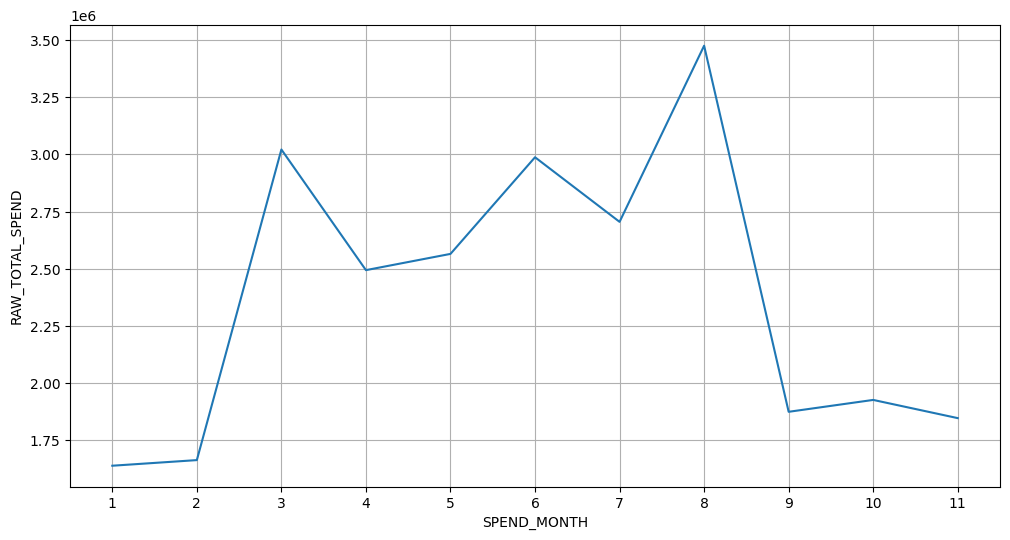

In [35]:
plt.figure(figsize=(12, 6))
plt.grid(True)

sns.lineplot(oh, x='SPEND_MONTH', y='RAW_TOTAL_SPEND')
plt.xticks(range(1,12))
plt.show()

Ohio sales pattern is not that different from overall pattern of Dick's, with in-season buying from March to August, representing a tendency from customers of buying sports equipment for Spring and Summer months.

In [36]:
# Explore percent change vs previous month and same month previous year

dicks[['PLACEKEY', 'RAW_TOTAL_SPEND', 'SPEND_MONTH', 'SPEND_PCT_CHANGE_VS_PREV_MONTH']].sort_values(by='SPEND_PCT_CHANGE_VS_PREV_MONTH', ascending=False).head()

,PLACEKEY,RAW_TOTAL_SPEND,SPEND_MONTH,SPEND_PCT_CHANGE_VS_PREV_MONTH
1588,222-222@8gf-dng-yvz,87395.98,3,34971.0
5667,224-222@8tm-pd3-kvf,11839.12,10,9741.0
5404,222-222@8dg-gcn-f9f,20996.02,10,7957.0
3370,222-222@5z7-s53-jjv,831.85,6,5842.0
1307,222-222@8gg-hx9-bff,26139.28,3,5454.0


There is something wrong in both the Percent change vs previous month and year of some stores/records. The Total spend, Number of customers, and Number of transactions at these locations suddenly jumped to a unprecedented level at some points in 2025.

It could indicate discrepancies in PLACEKEY assignment.

#### Compare Ohio to all Dick's

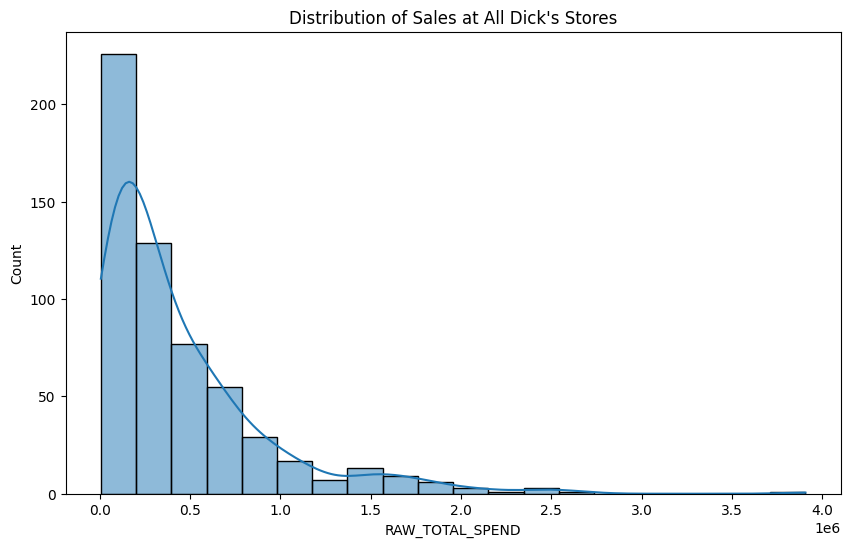

In [37]:
all_store_sales = dicks.groupby('PLACEKEY')['RAW_TOTAL_SPEND'].sum().reset_index()

#store_sales.sort_values(by='RAW_TOTAL_SPEND', ascending=True).head(20)

plt.figure(figsize=(10, 6))

sns.histplot(all_store_sales['RAW_TOTAL_SPEND'], bins=20, kde=True)
plt.title("Distribution of Sales at All Dick's Stores")
plt.show()

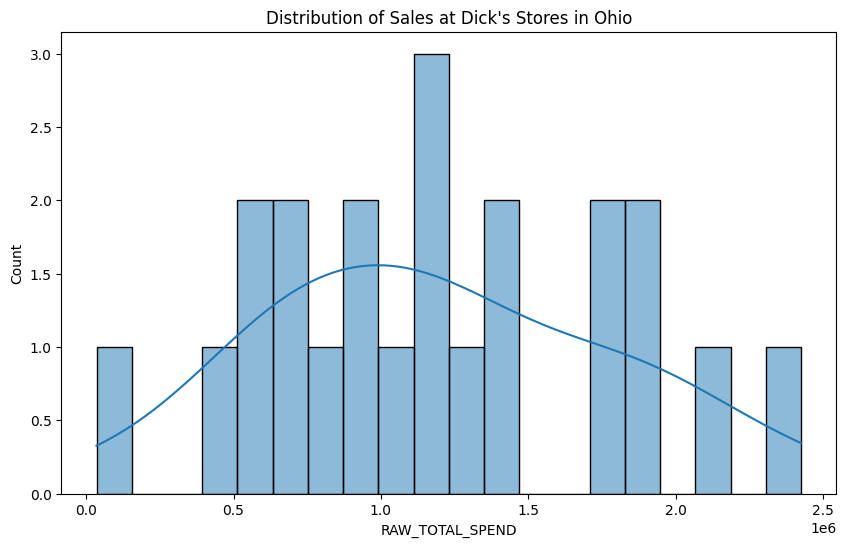

In [38]:
ohio = dicks[dicks['REGION'] == 'OH']
ohio_store_sales = ohio.groupby('PLACEKEY')['RAW_TOTAL_SPEND'].sum().reset_index()

plt.figure(figsize=(10, 6))

sns.histplot(ohio_store_sales['RAW_TOTAL_SPEND'], bins = 20, kde=True)
plt.title("Distribution of Sales at Dick's Stores in Ohio")
plt.show()

#### Demographics

In [39]:
# The only customer demographics information in this dataset is Income level. Therefore, we will dive into this aspect.

temp1 = df_sgt5_cleaned[['LOCATION_NAME', 'PLACEKEY', 'RAW_TOTAL_SPEND', 'RAW_NUM_CUSTOMERS', 'BUCKETED_CUSTOMER_INCOMES']].copy()
temp1.head()

,LOCATION_NAME,PLACEKEY,RAW_TOTAL_SPEND,RAW_NUM_CUSTOMERS,BUCKETED_CUSTOMER_INCOMES
2,Champs Sports,zzw-225@62k-p73-2p9,252.99,4,"{""100-150k"":2,""75-100k"":2,""<25k"":2}"
12,Champs Sports,zzw-22h@8gg-3jm-wrk,3010.11,25,"{""100-150k"":2,""25-45k"":2,""45-60k"":2,""60-75k"":2..."
26,Dick's Sporting Goods,222-222@5ny-jsb-9fz,1077.34,15,"{""100-150k"":2,""25-45k"":2,""60-75k"":2,""75-100k"":..."
30,Dick's Sporting Goods,222-222@5s6-ywp-qmk,35782.51,396,"{""100-150k"":58,""25-45k"":69,""45-60k"":42,""60-75k..."
34,Big 5 Sporting Goods,222-222@5z5-3pj-fvf,3539.77,63,"{""100-150k"":14,""25-45k"":8,""45-60k"":2,""60-75k"":..."


In [40]:
# Add blank columns to populate income data

income_columns = ['<25k', '25-45k', '45-60k', '60-75k', '75-100k', '100-150k', '>150k']

for i in income_columns:
  temp1[i] = ""

In [41]:
import ast

# Iterate through each row and extract income bucket values
for index, row in temp1.iterrows():
    # Safely evaluate the string to a dictionary
    income_data = ast.literal_eval(row['BUCKETED_CUSTOMER_INCOMES'])
    for col in income_columns:

        # Assign the value, default to 0 if the key is not found
        temp1.loc[index, col] = income_data.get(col, 0)

# Display the head of the DataFrame to show the new columns
display(temp1.head())

,LOCATION_NAME,PLACEKEY,RAW_TOTAL_SPEND,RAW_NUM_CUSTOMERS,BUCKETED_CUSTOMER_INCOMES,<25k,25-45k,45-60k,60-75k,75-100k,100-150k,>150k
2,Champs Sports,zzw-225@62k-p73-2p9,252.99,4,"{""100-150k"":2,""75-100k"":2,""<25k"":2}",2,0,0,0,2,2,0
12,Champs Sports,zzw-22h@8gg-3jm-wrk,3010.11,25,"{""100-150k"":2,""25-45k"":2,""45-60k"":2,""60-75k"":2...",3,2,2,2,2,2,6
26,Dick's Sporting Goods,222-222@5ny-jsb-9fz,1077.34,15,"{""100-150k"":2,""25-45k"":2,""60-75k"":2,""75-100k"":...",2,2,0,2,3,2,2
30,Dick's Sporting Goods,222-222@5s6-ywp-qmk,35782.51,396,"{""100-150k"":58,""25-45k"":69,""45-60k"":42,""60-75k...",60,69,42,24,44,58,85
34,Big 5 Sporting Goods,222-222@5z5-3pj-fvf,3539.77,63,"{""100-150k"":14,""25-45k"":8,""45-60k"":2,""60-75k"":...",2,8,2,2,9,14,17


In [42]:
grouped_income = temp1.groupby('LOCATION_NAME')[income_columns].sum().reset_index()

grouped_income.head()

,LOCATION_NAME,<25k,25-45k,45-60k,60-75k,75-100k,100-150k,>150k
0,Academy Sports + Outdoors,115773,137979,111587,90983,145086,196984,244057
1,Big 5 Sporting Goods,19226,22667,17597,13499,21795,27330,34371
2,Champs Sports,33503,34039,23230,16239,20268,20254,23954
3,Dick's Sporting Goods,289476,273534,203445,157337,250177,356078,582075
4,Hibbett Sports,6137,7791,6041,4438,5338,5312,5842


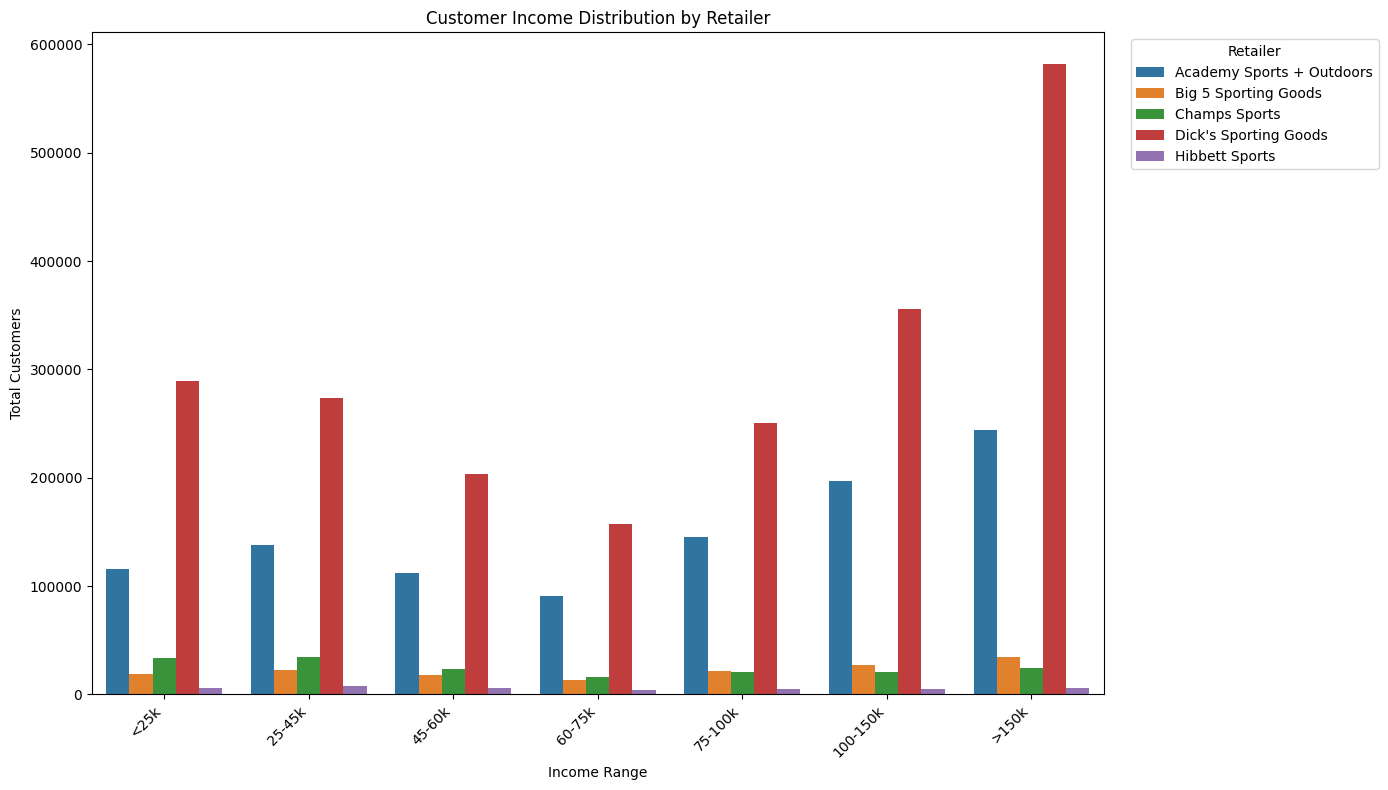

In [43]:
# Melt the grouped_income DataFrame to a long format
grouped_income_melted = grouped_income.melt(id_vars=['LOCATION_NAME'], var_name='Income_Range', value_name='Customer_Count')

plt.figure(figsize=(14, 8))
sns.barplot(data=grouped_income_melted, x='Income_Range', y='Customer_Count', hue='LOCATION_NAME')
plt.title('Customer Income Distribution by Retailer')
plt.xlabel('Income Range')
plt.ylabel('Total Customers')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Retailer', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

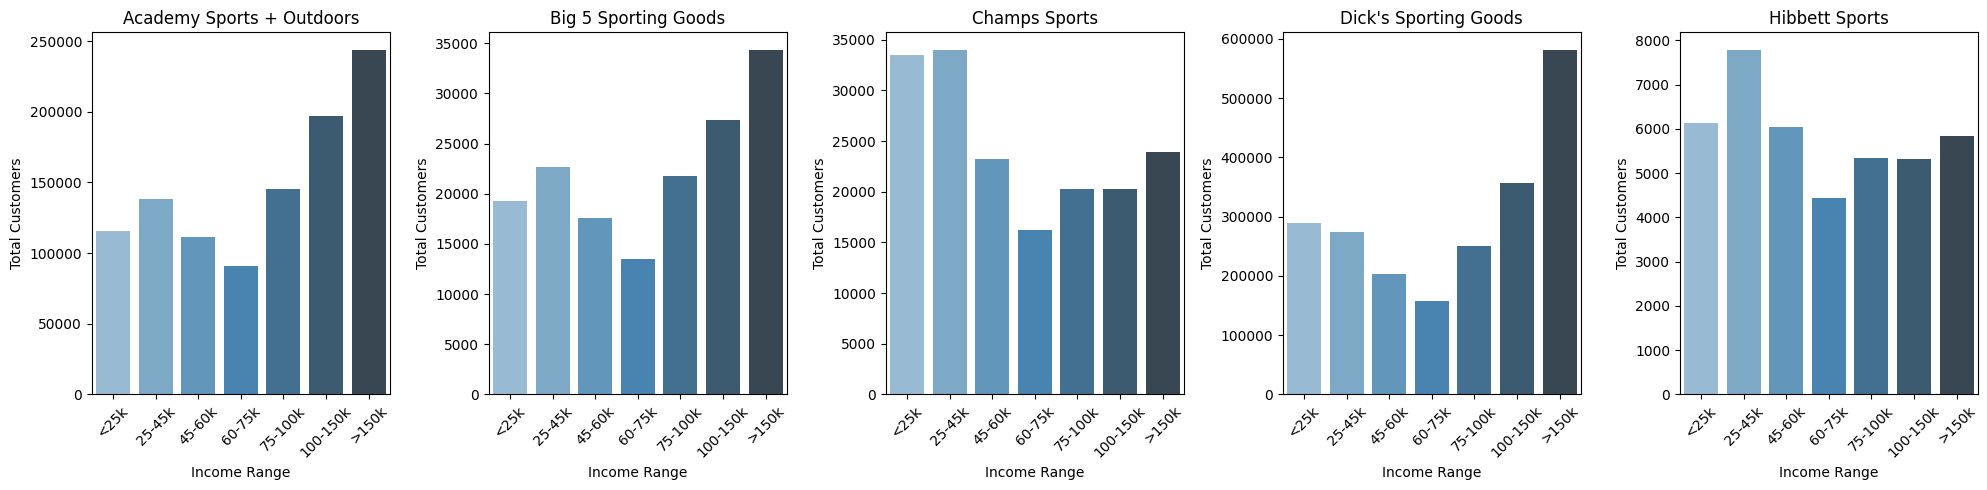

In [44]:
fig, axs = plt.subplots(1, 5, figsize=(20, 5))
retailer = grouped_income_melted['LOCATION_NAME'].unique()

for i in range(5):
  location_data = grouped_income_melted[grouped_income_melted['LOCATION_NAME'] == retailer[i]]

  sns.barplot(data=location_data, x='Income_Range', y='Customer_Count', hue='Income_Range', palette='Blues_d', ax = axs[i])

  axs[i].set_title(f'{retailer[i]}')
  axs[i].set_xlabel('Income Range')
  axs[i].set_ylabel('Total Customers')
  axs[i].tick_params(axis='x', labelrotation=45)


plt.tight_layout()
plt.show()